In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [16]:
data = np.array([10,20,30,40,50,60,70,80,90,100], dtype=float)

data = data / 100

In [17]:
X = []
y = []

for i in range(len(data) - 3):
    X.append(data[i:i+3])
    y.append(data[i+3])

X = np.array(X)
y = np.array(y)

In [18]:
X

array([[0.1, 0.2, 0.3],
       [0.2, 0.3, 0.4],
       [0.3, 0.4, 0.5],
       [0.4, 0.5, 0.6],
       [0.5, 0.6, 0.7],
       [0.6, 0.7, 0.8],
       [0.7, 0.8, 0.9]])

In [19]:
y

array([0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

In [20]:
X = X.reshape((X.shape[0], X.shape[1], 1))

In [21]:
X

array([[[0.1],
        [0.2],
        [0.3]],

       [[0.2],
        [0.3],
        [0.4]],

       [[0.3],
        [0.4],
        [0.5]],

       [[0.4],
        [0.5],
        [0.6]],

       [[0.5],
        [0.6],
        [0.7]],

       [[0.6],
        [0.7],
        [0.8]],

       [[0.7],
        [0.8],
        [0.9]]])

In [22]:
X.shape

(7, 3, 1)

In [23]:
model = Sequential()

model.add(LSTM(32, input_shape=(3, 1)))
model.add(Dense(1))

model.compile(optimizer='adam',loss='mse')

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 32)                  │           4,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history = model.fit(X,y,epochs=1000)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 0.4861
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - loss: 0.4722
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - loss: 0.4586
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.4452
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.4320
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - loss: 0.4189
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.4061
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.3934
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.3809
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.3686
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.3565
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - loss: 0.3445
Epoch 13/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - loss: 0.3327
Epoch 14/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - loss: 0.3210
Epoch 15/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - loss: 0.30

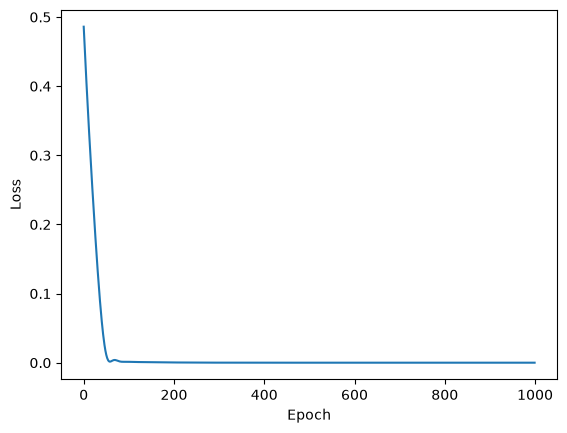

In [25]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [29]:
test = np.array([80, 90, 100])

test=test/100

test = test.reshape(1, 3, 1)

print(100*model.predict(test))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
[[111.508606]]


In [30]:
test = np.array([50, 60, 70])

test=test/100

test = test.reshape(1, 3, 1)

print(100*model.predict(test))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
[[79.54742]]
